# Notebook 07 — K-Nearest Neighbours (Stacked Dataset)
## ENGG2112 Project MODR

Fourth and final model in the comparison study. Same dataset (357 rows: flu + COVID + RSV), same CV strategy, same feature set as Notebooks 04–06.

### Why KNN
KNN is a non-parametric baseline: it makes no assumptions about the functional form of the relationship between features and outcome. It predicts by majority vote among the k nearest counties in feature space.

### Expected limitations
KNN is likely the weakest model here because:
1. **Curse of dimensionality** — with 10 features, distance metrics become less meaningful
2. **No class imbalance handling** — KNN has no `class_weight` parameter; at 26% positive rate, small k is needed to avoid always predicting the majority class
3. **No feature importance** — replaced with permutation importance for cross-model comparison

### Structure
1. Setup
2. Load data + feature matrix
3. Hyperparameter tuning (k, weights, metric)
4. Out-of-fold predictions
5. Performance metrics
6. Calibration
7. Permutation importance
8. Per-disease breakdown
9. Save model + metrics
10. Summary + full leaderboard

## 1. Setup

In [1]:
import json, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedGroupKFold, GridSearchCV, cross_val_predict
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, brier_score_loss,
    confusion_matrix, classification_report, roc_curve, precision_recall_curve
)
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression
from sklearn.inspection import permutation_importance

PROJECT_ROOT = Path.cwd().parent
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
MODELS_DIR = PROJECT_ROOT / 'models'
MODELS_DIR.mkdir(exist_ok=True)

plt.rcParams.update({'figure.figsize': (12, 6), 'axes.titlesize': 13, 'axes.labelsize': 11,
                     'figure.dpi': 100, 'axes.spines.top': False, 'axes.spines.right': False})
sns.set_style('whitegrid')

## 2. Load Data + Feature Matrix

In [2]:
master = pd.read_csv(PROCESSED_DIR / 'master_stacked.csv', dtype={'fips': str, 'state_fips': str})
with open(PROCESSED_DIR / 'selected_features.json') as f:
    fc = json.load(f)
DEMO = fc['demographic']
DISEASE_DUMMIES = fc['disease_dummies']
STATE_DUMMIES   = fc['state_dummies']

disease_X = pd.get_dummies(master['disease'], prefix='disease', drop_first=True).astype(float)
state_X   = pd.get_dummies(master['state'],   prefix='state',   drop_first=True).astype(float)
scaler    = StandardScaler()
demo_X    = pd.DataFrame(scaler.fit_transform(master[DEMO]), columns=DEMO, index=master.index)

X      = pd.concat([demo_X, disease_X[DISEASE_DUMMIES], state_X[STATE_DUMMIES]], axis=1)
y      = master['outbreak'].astype(int).values
groups = master['fips'].values

print(f'Stacked dataset: {master.shape}')
print(f'Feature matrix:  {X.shape}')
print(f'Features: {list(X.columns)}')
print(f'Outbreak rate: {y.mean():.1%}  |  Unique counties: {len(set(groups))}')

with open(MODELS_DIR / 'knn_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print('✅ knn_scaler.pkl saved')

Stacked dataset: (357, 40)
Feature matrix:  (357, 10)
Features: ['pct_foreign_born', 'pop_density_per_sqmi', 'avg_household_size', 'public_transport_pct', 'pct_elderly', 'disease_FLU', 'disease_RSV', 'state_DE', 'state_NY', 'state_PA']
Outbreak rate: 26.1%  |  Unique counties: 149
✅ knn_scaler.pkl saved


## 3. Hyperparameter Tuning via GridSearchCV

KNN's key hyperparameters:
- `n_neighbors` (k): small k → sensitive to noise; large k → biased toward majority class (bad for 26% positive rate)
- `weights`: `uniform` = majority vote; `distance` = closer neighbours count more
- `metric`: `euclidean` vs `manhattan` — Manhattan is often better in higher dimensions

No class imbalance parameter exists in KNN. `weights='distance'` partially compensates by giving minority-class neighbours more influence when they're close.

In [3]:
cv = StratifiedGroupKFold(n_splits=5)

param_grid = {
    'n_neighbors': [3, 5, 7, 11, 15, 21],
    'weights':     ['uniform', 'distance'],
    'metric':      ['euclidean', 'manhattan'],
}

grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid=param_grid,
    cv=cv,
    scoring='average_precision',
    n_jobs=-1,
    verbose=0,
)
grid.fit(X, y, groups=groups)

print(f'Best params:  {grid.best_params_}')
print(f'Best PR-AUC:  {grid.best_score_:.3f}')

results_df = pd.DataFrame(grid.cv_results_)
top5 = results_df.nlargest(5, 'mean_test_score')[['params', 'mean_test_score', 'std_test_score']]
print(f'\nTop 5 configs:')
for _, row in top5.iterrows():
    print(f'  PR-AUC = {row["mean_test_score"]:.3f} ± {row["std_test_score"]:.3f}  |  {row["params"]}')

Best params:  {'metric': 'manhattan', 'n_neighbors': 21, 'weights': 'distance'}
Best PR-AUC:  0.538

Top 5 configs:
  PR-AUC = 0.538 ± 0.030  |  {'metric': 'manhattan', 'n_neighbors': 21, 'weights': 'distance'}
  PR-AUC = 0.530 ± 0.027  |  {'metric': 'manhattan', 'n_neighbors': 21, 'weights': 'uniform'}
  PR-AUC = 0.518 ± 0.036  |  {'metric': 'manhattan', 'n_neighbors': 15, 'weights': 'distance'}
  PR-AUC = 0.514 ± 0.049  |  {'metric': 'manhattan', 'n_neighbors': 15, 'weights': 'uniform'}
  PR-AUC = 0.503 ± 0.054  |  {'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'distance'}


## 4. Out-of-Fold Predictions

In [4]:
best_knn = KNeighborsClassifier(**grid.best_params_)

oof_proba = cross_val_predict(best_knn, X, y, cv=cv, method='predict_proba', groups=groups)[:, 1]
oof_pred  = (oof_proba >= 0.5).astype(int)

# Final model on all data
model = KNeighborsClassifier(**grid.best_params_)
model.fit(X, y)
print(f'KNN fitted: k={grid.best_params_["n_neighbors"]}, '
      f'weights={grid.best_params_["weights"]}, metric={grid.best_params_["metric"]}')

KNN fitted: k=21, weights=distance, metric=manhattan


## 5. Performance Metrics

In [5]:
positive_rate = y.mean()

metrics = {
    'accuracy':  accuracy_score(y, oof_pred),
    'precision': precision_score(y, oof_pred, zero_division=0),
    'recall':    recall_score(y, oof_pred, zero_division=0),
    'f1':        f1_score(y, oof_pred, zero_division=0),
    'roc_auc':   roc_auc_score(y, oof_proba),
    'pr_auc':    average_precision_score(y, oof_proba),
    'brier':     brier_score_loss(y, oof_proba),
}

print('Cross-validated metrics (out-of-fold, StratifiedGroupKFold):\n')
for k, v in metrics.items():
    marker = ' ← HEADLINE' if k == 'pr_auc' else ''
    print(f'  {k:<12s}: {v:.3f}{marker}')

print(f'\nBaselines:')
print(f'  Random PR-AUC:        {positive_rate:.3f}')
print(f'  Always-zero accuracy: {1 - positive_rate:.3f}')
print(f'\n{classification_report(y, oof_pred, target_names=["Non-outbreak", "Outbreak"])}')

Cross-validated metrics (out-of-fold, StratifiedGroupKFold):

  accuracy    : 0.782
  precision   : 0.800
  recall      : 0.215
  f1          : 0.339
  roc_auc     : 0.687
  pr_auc      : 0.510 ← HEADLINE
  brier       : 0.170

Baselines:
  Random PR-AUC:        0.261
  Always-zero accuracy: 0.739

              precision    recall  f1-score   support

Non-outbreak       0.78      0.98      0.87       264
    Outbreak       0.80      0.22      0.34        93

    accuracy                           0.78       357
   macro avg       0.79      0.60      0.60       357
weighted avg       0.79      0.78      0.73       357



## 6. Calibration

KNN probabilities are crude — they're the fraction of k neighbours in the positive class, which takes only a few discrete values (0/k, 1/k, ..., k/k). Isotonic regression smooths this into proper probabilities for the SIR simulation.

Brier score:
  Uncalibrated:        0.170
  Isotonic-calibrated: 0.159
  Improvement:         +0.011


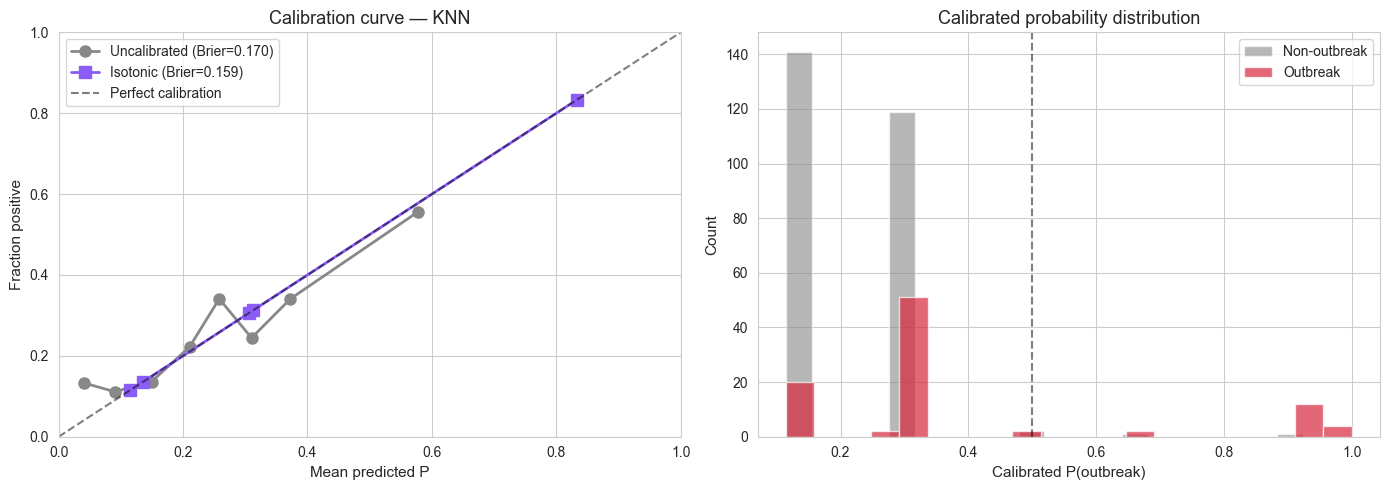

In [6]:
prob_true_uncal, prob_pred_uncal = calibration_curve(y, oof_proba, n_bins=8, strategy='quantile')
brier_uncal = metrics['brier']

iso = IsotonicRegression(out_of_bounds='clip')
iso.fit(oof_proba, y)
calibrated_proba = iso.predict(oof_proba)

prob_true_cal, prob_pred_cal = calibration_curve(y, calibrated_proba, n_bins=8, strategy='quantile')
brier_cal = brier_score_loss(y, calibrated_proba)

print(f'Brier score:')
print(f'  Uncalibrated:        {brier_uncal:.3f}')
print(f'  Isotonic-calibrated: {brier_cal:.3f}')
print(f'  Improvement:         {brier_uncal - brier_cal:+.3f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(prob_pred_uncal, prob_true_uncal, 'o-', color='#888888', lw=2, ms=8,
        label=f'Uncalibrated (Brier={brier_uncal:.3f})')
ax.plot(prob_pred_cal,   prob_true_cal,   's-', color='#8B5CF6', lw=2, ms=8,
        label=f'Isotonic (Brier={brier_cal:.3f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect calibration')
ax.set_xlabel('Mean predicted P'); ax.set_ylabel('Fraction positive')
ax.set_title('Calibration curve — KNN'); ax.legend()
ax.set_xlim(0, 1); ax.set_ylim(0, 1)

ax = axes[1]
ax.hist(calibrated_proba[y == 0], bins=20, alpha=0.6, color='#888888',
        label='Non-outbreak', edgecolor='white')
ax.hist(calibrated_proba[y == 1], bins=20, alpha=0.7, color='#D7263D',
        label='Outbreak',     edgecolor='white')
ax.axvline(0.5, color='black', linestyle='--', alpha=0.5)
ax.set_xlabel('Calibrated P(outbreak)'); ax.set_ylabel('Count')
ax.set_title('Calibrated probability distribution'); ax.legend()

plt.tight_layout(); plt.show()

## 7. Permutation Importance

KNN has no built-in feature importance. Permutation importance is the only model-agnostic option — and using the same method as Notebooks 05–06 makes cross-model comparison valid.

Permutation importance (drop in PR-AUC):

  avg_household_size          : +0.3335 ± 0.0311
  pct_elderly                 : +0.3142 ± 0.0235
  disease_FLU                 : +0.2967 ± 0.0241
  pct_foreign_born            : +0.2255 ± 0.0190
  disease_RSV                 : +0.1840 ± 0.0243
  state_PA                    : +0.0818 ± 0.0151
  state_NY                    : +0.0665 ± 0.0135
  public_transport_pct        : +0.0372 ± 0.0091
  pop_density_per_sqmi        : +0.0106 ± 0.0033
  state_DE                    : +0.0002 ± 0.0003


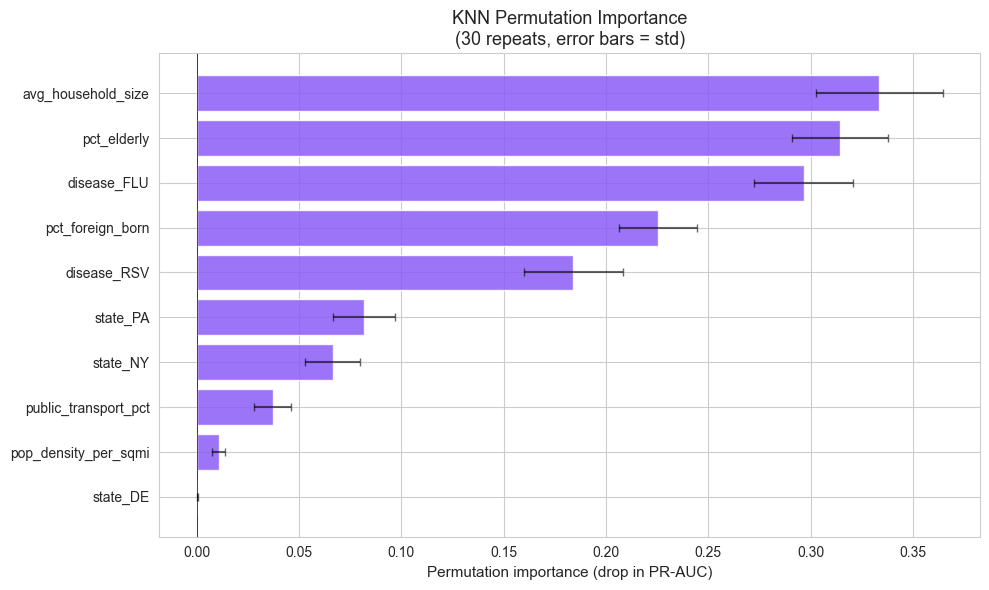

In [7]:
perm = permutation_importance(
    model, X, y, n_repeats=30, random_state=42, n_jobs=-1, scoring='average_precision'
)
perm_imp   = pd.Series(perm.importances_mean, index=X.columns).sort_values(ascending=False)
perm_std_s = pd.Series(perm.importances_std,  index=X.columns)

print('Permutation importance (drop in PR-AUC):\n')
for feat in perm_imp.index:
    print(f'  {feat:<28s}: {perm_imp[feat]:+.4f} ± {perm_std_s[feat]:.4f}')

fig, ax = plt.subplots(figsize=(10, 6))
sorted_p   = perm_imp.sort_values()
sorted_std = perm_std_s.reindex(sorted_p.index)
ax.barh(sorted_p.index, sorted_p.values, xerr=sorted_std.values,
        color='#8B5CF6', edgecolor='white', alpha=0.85,
        error_kw={'ecolor': 'black', 'capsize': 3, 'alpha': 0.6})
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel('Permutation importance (drop in PR-AUC)')
ax.set_title('KNN Permutation Importance\n(30 repeats, error bars = std)')
plt.tight_layout(); plt.show()

## 8. Per-Disease Breakdown

In [8]:
per_pred_df = pd.DataFrame({
    'disease': master['disease'].values,
    'true':    y,
    'pred':    oof_pred,
    'proba':   oof_proba,
    'proba_calibrated': calibrated_proba,
})

per_disease = per_pred_df.groupby('disease').apply(lambda g: pd.Series({
    'n':               len(g),
    'positives':       int(g['true'].sum()),
    'pr_auc':          round(average_precision_score(g['true'], g['proba']), 3) if g['true'].sum() > 0 else float('nan'),
    'pr_auc_calibrated': round(average_precision_score(g['true'], g['proba_calibrated']), 3) if g['true'].sum() > 0 else float('nan'),
    'roc_auc':         round(roc_auc_score(g['true'], g['proba']), 3) if g['true'].nunique() == 2 else float('nan'),
    'accuracy':        round(accuracy_score(g['true'], g['pred']), 3),
}), include_groups=False)

print('Per-disease performance (KNN):\n')
print(per_disease.to_string())

lr_path = MODELS_DIR / 'lr_metrics.json'
rf_path = MODELS_DIR / 'rf_metrics.json'
xgb_path = MODELS_DIR / 'xgb_metrics.json'
if all(p.exists() for p in [lr_path, rf_path, xgb_path]):
    with open(lr_path)  as f: lr_m  = json.load(f)
    with open(rf_path)  as f: rf_m  = json.load(f)
    with open(xgb_path) as f: xgb_m = json.load(f)
    print('\n=== Per-disease PR-AUC: LR vs RF vs XGB vs KNN ===')
    for disease in per_disease.index:
        lr_v  = lr_m.get( 'per_disease_performance', {}).get(disease, {}).get('pr_auc', float('nan'))
        rf_v  = rf_m.get( 'per_disease_performance', {}).get(disease, {}).get('pr_auc', float('nan'))
        xgb_v = xgb_m.get('per_disease_performance', {}).get(disease, {}).get('pr_auc', float('nan'))
        knn_v = float(per_disease.loc[disease, 'pr_auc'])
        vals  = [v for v in [lr_v, rf_v, xgb_v, knn_v] if not (v != v)]
        best  = max(vals) if vals else float('nan')
        print(f'  {disease}: LR={lr_v:.3f}  RF={rf_v:.3f}  XGB={xgb_v:.3f}  KNN={knn_v:.3f}  [best={best:.3f}]')

Per-disease performance (KNN):

             n  positives  pr_auc  pr_auc_calibrated  roc_auc  accuracy
disease                                                                
COVID    140.0       36.0   0.626              0.586    0.749     0.814
FLU      141.0       37.0   0.484              0.502    0.663     0.780
RSV       76.0       20.0   0.326              0.312    0.583     0.724

=== Per-disease PR-AUC: LR vs RF vs XGB vs KNN ===
  COVID: LR=0.554  RF=0.653  XGB=0.636  KNN=0.626  [best=0.653]
  FLU: LR=0.479  RF=0.470  XGB=0.453  KNN=0.484  [best=0.484]
  RSV: LR=0.228  RF=0.287  XGB=0.319  KNN=0.326  [best=0.326]


## 9. Save Model + Metrics

Schema matches `rf_metrics.json` for clean loading in Notebook 08.

In [9]:
artifact = {
    'model': model,
    'isotonic_calibrator': iso,
    'scaler': scaler,
    'feature_names': list(X.columns),
    'best_params': grid.best_params_,
    'metrics': metrics,
}
with open(MODELS_DIR / 'knn_model.pkl', 'wb') as f:
    pickle.dump(artifact, f)
print('✅ models/knn_model.pkl')

per_disease_export = {}
for disease, row in per_disease.iterrows():
    per_disease_export[disease] = {
        'n':                 int(row['n']),
        'positives':         int(row['positives']),
        'pr_auc':            float(row['pr_auc']),
        'pr_auc_calibrated': float(row['pr_auc_calibrated']),
        'roc_auc':           float(row['roc_auc']) if row['roc_auc'] == row['roc_auc'] else None,
        'accuracy':          float(row['accuracy']),
    }

metrics_export = {
    'model':               'KNN',
    'dataset':             'master_stacked.csv',
    'n_observations':      int(len(y)),
    'n_features':          int(X.shape[1]),
    'positive_class_rate': float(y.mean()),
    'cv_strategy':         'StratifiedGroupKFold(n_splits=5, groups=fips)',
    'best_params':         grid.best_params_,
    'cv_metrics':          {k: float(v) for k, v in metrics.items()},
    'cv_metrics_calibrated': {'brier': float(brier_cal)},
    'baseline_pr_auc':     float(positive_rate),
    'feature_importance':  {
        'permutation':     {f: float(v) for f, v in perm_imp.items()},
        'permutation_std': {f: float(v) for f, v in perm_std_s.items()},
    },
    'per_disease_performance': per_disease_export,
}
with open(MODELS_DIR / 'knn_metrics.json', 'w') as f:
    json.dump(metrics_export, f, indent=2)
print('✅ models/knn_metrics.json')

✅ models/knn_model.pkl
✅ models/knn_metrics.json


## 10. Summary + Full Leaderboard

In [10]:
print('=== NOTEBOOK 07 — KNN SUMMARY ===\n')
print(f'Best params: k={grid.best_params_["n_neighbors"]}, '
      f'weights={grid.best_params_["weights"]}, metric={grid.best_params_["metric"]}')
print(f'\nHeadline metrics (5-fold StratifiedGroupKFold CV):')
for k, v in metrics.items():
    marker = ' ← HEADLINE' if k == 'pr_auc' else ''
    print(f'  {k:<12s}: {v:.3f}{marker}')
print(f'  brier (cal):  {brier_cal:.3f}')

print(f'\n=== FULL LEADERBOARD (PR-AUC, StratifiedGroupKFold) ===')
all_metrics = [
    ('Logistic Regression', lr_m['cv_metrics']['pr_auc'],  lr_m['cv_metrics']['roc_auc'],  lr_m['cv_metrics']['brier']),
    ('Random Forest',       rf_m['cv_metrics']['pr_auc'],  rf_m['cv_metrics']['roc_auc'],  rf_m['cv_metrics']['brier']),
    ('XGBoost',            xgb_m['cv_metrics']['pr_auc'], xgb_m['cv_metrics']['roc_auc'], xgb_m['cv_metrics']['brier']),
    ('KNN',                 metrics['pr_auc'],              metrics['roc_auc'],              metrics['brier']),
]
all_metrics.sort(key=lambda x: -x[1])
print(f'\n  {"Model":<22}  {"PR-AUC":>7}  {"ROC-AUC":>8}  {"Brier":>6}')
print('  ' + '-' * 50)
for rank, (name, pr, roc, brier_v) in enumerate(all_metrics, 1):
    tag = ' ← BEST' if rank == 1 else ''
    print(f'  {rank}. {name:<20}  {pr:>7.3f}  {roc:>8.3f}  {brier_v:>6.3f}{tag}')
print(f'  Baseline PR-AUC (random): {positive_rate:.3f}')
print(f'\n👉 Next: Notebook 08 — final model comparison + production model selection')

=== NOTEBOOK 07 — KNN SUMMARY ===

Best params: k=21, weights=distance, metric=manhattan

Headline metrics (5-fold StratifiedGroupKFold CV):
  accuracy    : 0.782
  precision   : 0.800
  recall      : 0.215
  f1          : 0.339
  roc_auc     : 0.687
  pr_auc      : 0.510 ← HEADLINE
  brier       : 0.170
  brier (cal):  0.159

=== FULL LEADERBOARD (PR-AUC, StratifiedGroupKFold) ===

  Model                    PR-AUC   ROC-AUC   Brier
  --------------------------------------------------
  1. KNN                     0.510     0.687   0.170 ← BEST
  2. Random Forest           0.506     0.652   0.177
  3. XGBoost                 0.491     0.665   0.198
  4. Logistic Regression     0.446     0.610   0.231
  Baseline PR-AUC (random): 0.261

👉 Next: Notebook 08 — final model comparison + production model selection
